**This notebook will demonstrate using XGBoost for regression and classification using the Sklearn API**

First, we'll load packages and import the data.

In [28]:
import pandas as pd
# import numpy as np
# import xgboost as xgb
import sklearn as skl
import matplotlib as plt
# from xgboost import XGBClassifier

df = pd.read_csv('NHANES.csv').drop(["Unnamed: 0", "SEQN"], axis=1)

In [29]:
# One-hot encode gender
df['gender_M'] = (df['gender']=='male').astype(int)

# One-hot encode 'med_hbp' into 'med_hbp_T' and 'med_hbp_F'
# By creating two columns for T and F, we handle all of the NaN values like a third category
df['med_hbp_T'] = (df['med_hbp'] == True).astype(int)
df['med_hbp_F'] = (df['med_hbp'] == False).astype(int)

# One-hot encode 'med_chol' into 'med_chol_T' and 'med_chol_F'
df['med_chol_T'] = (df['med_chol'] == True).astype(int)
df['med_chol_F'] = (df['med_chol'] == False).astype(int)

# Select boolean columns
bool_columns = df.select_dtypes(include=['bool']).columns

# Convert boolean columns to integers
df[bool_columns] = df[bool_columns].astype(int)

# Drop all columns that needed cleaning or re-encoding
df.drop(['gender', 'med_hbp', 'med_chol'], axis=1, inplace=True)

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(['extreme_bp','bp_sys','bp_di'], axis=1)
y = df.bp_sys

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1802)

In [32]:
from xgboost import XGBRegressor

boost_reg_model = XGBRegressor(n_estimators=100, 
                               max_depth=6, # max depth of each tree; deeper models are more complex
                               objective='reg:squarederror',
                               eval_metric='rmse',
                               learning_rate=0.1, # Eta; 0-1, where 1 is the highest/quickest (not best)
                               gamma=0, # min_split_loss; (0, inf) higher is more conservative
                               reg_alpha=0, # L1 regularization (0, inf) higher is more conservative
                               reg_lambda=1, # L2 regularization (0, inf) higher is more conservative
                               verbosity=1, # Verbosity level: 0-silent, 1-errors, 2-info, 3-debugging
                               tree_method='hist', # auto / hist, approx, exact; exact enumerates (more acc, but slow)
                               grow_policy='lossguide',
                               sampling_method='uniform',
                               random_state=1802
                              )

In [33]:
boost_reg_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=0, grow_policy='lossguide', importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=1802, ...)

In [35]:
bp_sys_boost_pred = boost_reg_model.predict(X_test)

In [36]:
import sklearn as skl

print('mean absolute error: ', round(skl.metrics.mean_absolute_error(y_test, bp_sys_boost_pred),1))
print('R Squared: ', round(skl.metrics.r2_score(y_test, bp_sys_boost_pred),4))


mean absolute error:  10.9
R Squared:  0.385


In [21]:
X_class = df.drop(['extreme_bp','bp_sys','bp_di'], axis=1)
y_class = df.extreme_bp

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, stratify=y_class, random_state=42)

In [40]:
from sklearn.linear_model import LinearRegression

# Create an instance of LinearRegression
linreg_model = LinearRegression()

# Fit the model to your training data
linreg_model.fit(X_train_class, y_train_class)

# make predictions with the linear model
bp_sys_linreg_pred = linreg_model.predict(X_test)

In [41]:
print('linear regression mean absolute error: ', round(skl.metrics.mean_absolute_error(y_test, bp_sys_linreg_pred),1))
print('R Squared: ', round(skl.metrics.r2_score(y_test, bp_sys_linreg_pred),4))

linear regression mean absolute error:  122.1
R Squared:  -41.1532


In [49]:
from xgboost import XGBClassifier


boost_cat_model = XGBClassifier(n_estimators=100, 
                               max_depth=6, # max depth of each tree; deeper models are more complex
                               objective='binary:logistic',
                               eval_metric='auc',
                               learning_rate=0.1, # Eta; 0-1, where 1 is the highest/quickest (not best)
                               gamma=0, # min_split_loss; (0, inf) higher is more conservative
                               reg_alpha=0, # L1 regularization (0, inf) higher is more conservative
                               reg_lambda=1, # L2 regularization (0, inf) higher is more conservative
                               verbosity=1, # Verbosity level: 0-silent, 1-errors, 2-info, 3-debugging
                               tree_method='hist', # auto / hist, approx, exact; exact enumerates (more acc, but slow)
                               grow_policy='lossguide',
                               sampling_method='uniform',
                               random_state=1802
                              )

In [50]:
boost_cat_model.fit(X_train_class, y_train_class)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=0, grow_policy='lossguide', importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=1802, ...)

In [43]:
from sklearn import linear_model
log_model=linear_model.LogisticRegression()

# Fit the model to your training data
log_model.fit(X_train_class, y_train_class)

# make predictions with the linear model
extreme_bp_log_pred = log_model.predict(X_test)

C:\Users\brenden.siekman\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
print('Accuracy: ',round(skl.metrics.accuracy_score(y_test_class, extreme_bp_log_pred),4))

Accuracy:  0.5787


In [52]:
extreme_bp_pred = boost_cat_model.predict(X_test_class)

In [115]:
cm = skl.metrics.confusion_matrix(y_test_class, extreme_bp_pred)
cm

array([[259,  43],
       [ 54,  95]], dtype=int64)

In [73]:
print('Logistic Regression Accuracy: ',round(skl.metrics.accuracy_score(y_test_class, extreme_bp_log_pred),4))
print('Logistic Regression AUC: ', round(skl.metrics.roc_auc_score(y_test_class, extreme_bp_log_pred),4))

print('XGBoost Accuracy: ',round(skl.metrics.accuracy_score(y_test_class, extreme_bp_pred),4))
print('XGBoost AUC: ', round(skl.metrics.roc_auc_score(y_test_class, extreme_bp_pred),4))

Logistic Regression Accuracy:  0.5787
Logistic Regression AUC:  0.5001
XGBoost Accuracy:  0.796
XGBoost AUC:  0.7593


In [111]:
round(1510/2255, 4)

0.6696

In [56]:
log_model_cv = skl.linear_model.LogisticRegressionCV(cv=5, random_state=1802).fit(X_train_class, y_train_class)

C:\Users\brenden.siekman\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\brenden.siekman\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules

In [58]:
cv_log_model_preds = log_model_cv.predict(X_test_class)

In [63]:
print("Mean accuracy using cross-validated tuned parameter logistic regression: ", round(log_model_cv.score(X_test_class, y_test_class),4))

Mean accuracy using cross-validated tuned parameter logistic regression:  0.7827


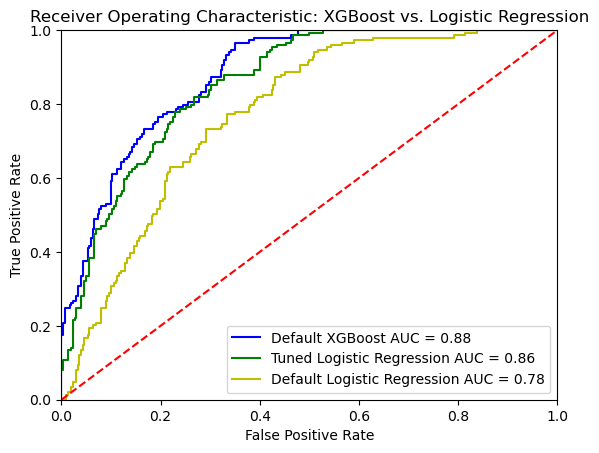

In [77]:
# adapted from https://stackoverflow.com/questions/25009284/how-to-plot-roc-curve-in-python

import sklearn.metrics as metrics
# calculate the fpr and tpr for all thresholds of the classification
probs = boost_cat_model.predict_proba(X_test_class)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test_class, preds)
roc_auc = metrics.auc(fpr, tpr)

probs2 = log_model_cv.predict_proba(X_test_class)
preds2 = probs2[:,1]
fpr2, tpr2, threshold2 = metrics.roc_curve(y_test_class, preds2)
roc_auc2 = metrics.auc(fpr2, tpr2)

probs3 = log_model.predict_proba(X_test_class)
preds3 = probs3[:,1]
fpr3, tpr3, threshold3 = metrics.roc_curve(y_test_class, preds3)
roc_auc3 = metrics.auc(fpr3, tpr3)


# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic: XGBoost vs. Logistic Regression')
plt.plot(fpr, tpr, 'b', label = 'Default XGBoost AUC = %0.2f' % roc_auc)
plt.plot(fpr2, tpr2, 'g', label = 'Tuned Logistic Regression AUC = %0.2f' % roc_auc2)
plt.plot(fpr3, tpr3, 'y', label = 'Default Logistic Regression AUC = %0.2f' % roc_auc3)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()